In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [31]:
hydrology_data = pd.read_csv('output/CSVs/om/saved_variables_csv_evap_bug_hydrology.txt_11-Oct-2023_Wed_10-37-57.csv')

In [32]:
hydrology_data.columns

Index(['Time.day.values', 'Time.year.values', 'Time.calendar_year.values',
       'field='regular'.max_evapotranspiration.values',
       'field='regular'.water_evaporated.values',
       'field='regular',layer_index='0'.water_content.values',
       'field='regular',layer_index='0'.evaporated_water_content.values',
       'field='regular',layer_index='1'.water_content.values',
       'field='regular',layer_index='1'.evaporated_water_content.values',
       'field='regular',layer_index='2'.water_content.values',
       'field='regular',layer_index='2'.evaporated_water_content.values',
       'field='regular',layer_index='3'.water_content.values',
       'field='regular',layer_index='3'.evaporated_water_content.values',
       'field='sandy'.max_evapotranspiration.values',
       'field='sandy'.water_evaporated.values',
       'field='sandy',layer_index='0'.water_content.values',
       'field='sandy',layer_index='0'.evaporated_water_content.values',
       'field='sandy',layer_index='1

In [ ]:
top_pre_infil = hydrology_data["Field.top_water_content_pre_infiltration(mm).values"].tolist()
top_post_infil = hydrology_data["Field.top_water_content_post_infiltration(mm).values"].tolist()
infiltration = hydrology_data["Field.infiltrated_water(mm).values"].tolist()
top_pre_perc = hydrology_data["Field.top_water_content_pre_percolation(mm).values"].tolist()
second_pre_perc = hydrology_data["Field.second_layer_water_content_pre_percolation(mm).values"].tolist()

In [5]:
field_name = "regular"

In [33]:
top_layer = hydrology_data[f"field='{field_name}',layer_index='0'.water_content.values"].tolist()
second_layer = hydrology_data[f"field='{field_name}',layer_index='1'.water_content.values"].tolist()
third_layer = hydrology_data[f"field='{field_name}',layer_index='2'.water_content.values"].tolist()
fourth_layer = hydrology_data[f"field='{field_name}',layer_index='3'.water_content.values"].tolist()

In [34]:
total_evap = hydrology_data[f"field='{field_name}'.water_evaporated.values"].tolist()
max_evapotranspiration = hydrology_data[f"field='{field_name}'.max_evapotranspiration.values"].tolist()
top_evap = hydrology_data[f"field='{field_name}',layer_index='0'.evaporated_water_content.values"].tolist()
second_evap = hydrology_data[f"field='{field_name}',layer_index='1'.evaporated_water_content.values"].tolist()
third_evap = hydrology_data[f"field='{field_name}',layer_index='2'.evaporated_water_content.values"].tolist()
fourth_evap = hydrology_data[f"field='{field_name}',layer_index='3'.evaporated_water_content.values"].tolist()

In [24]:
top_percolation = hydrology_data[f"field='{field_name}',layer_index='0'.percolated_water.values"].tolist()
second_percolation = hydrology_data[f"field='{field_name}',layer_index='1'.percolated_water.values"].tolist()
third_percolation = hydrology_data[f"field='{field_name}',layer_index='2'.percolated_water.values"].tolist()
fourth_percolation = hydrology_data[f"field='{field_name}',layer_index='3'.percolated_water.values"].tolist()
infiltration = hydrology_data[f"field='{field_name}'.infiltrated_water.values"].tolist()

In [36]:
days = hydrology_data["Time.day.values"].tolist()
years = hydrology_data["Time.year.values"].tolist()
dates = [f"{day}/{year}" for day, year in zip(days, years)]

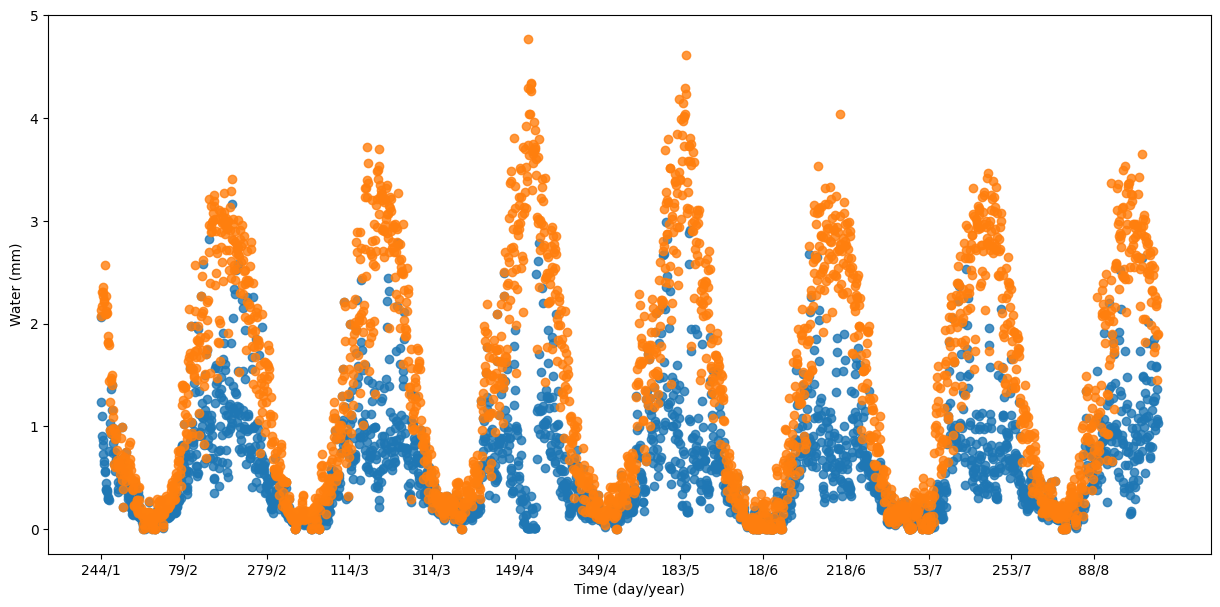

In [37]:
start_date = 0
end_date = -1
x_axis = dates[start_date:end_date]
x_ticks = dates[start_date:end_date:200]
total = total_evap[start_date:end_date]
max_evap = max_evapotranspiration[start_date:end_date]
top = top_layer[start_date:end_date]
second = second_layer[start_date:end_date]
third = third_layer[start_date:end_date]
fourth = fourth_layer[start_date:end_date]
plt.figure(figsize=(15, 7))
plt.plot(x_axis, total, 'o', alpha=0.8)
plt.plot(x_axis, max_evap, 'o', alpha=0.8)
"""
plt.plot(x_axis, top, 'o-', alpha=0.8)
plt.plot(x_axis, second, 'o--', alpha=0.4)
plt.plot(x_axis, third, 'o-.', alpha=0.4)
plt.plot(x_axis, fourth, 'o:', alpha=0.4)
"""
plt.xticks(x_ticks, rotation=0)
plt.xlabel("Time (day/year)")
plt.ylabel("Water (mm)")
#plt.legend(["Surface Layer Water Content", "Second Layer Water Content", "Third Layer Water Content", "Fourth Layer Water Content"], loc="upper right")
plt.savefig("hyrodology_plot.png")
plt.show()

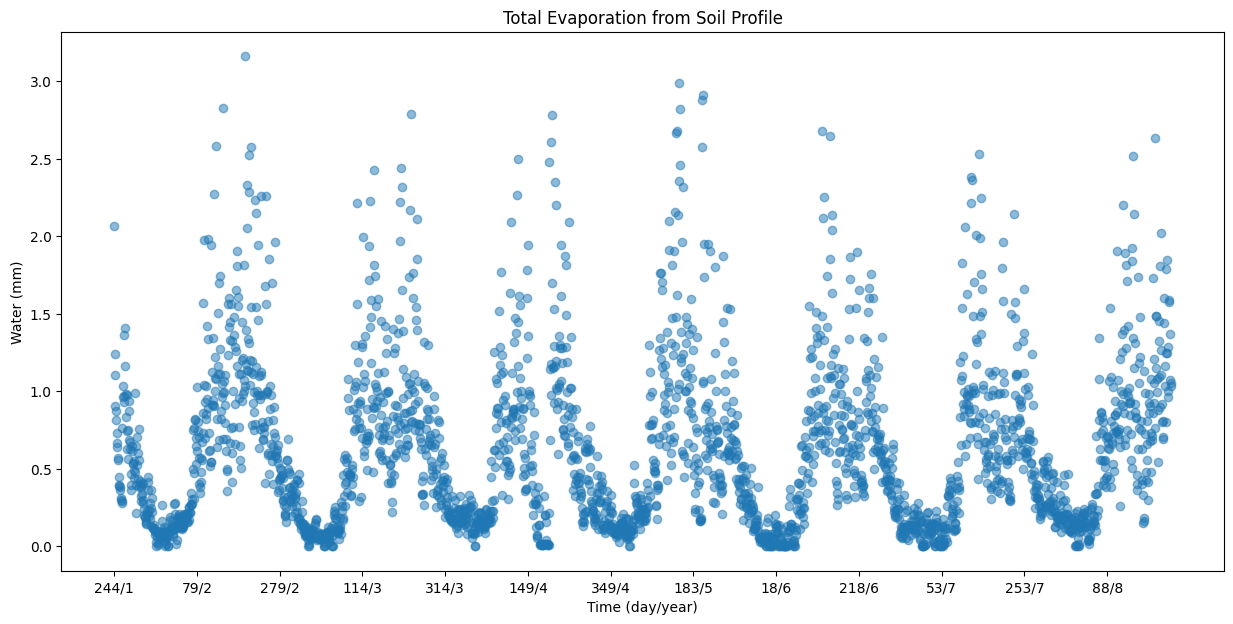

In [42]:
start_date = 0
end_date = -1
x_axis = dates[start_date:end_date]
x_ticks = dates[start_date:end_date:200]
total = total_evap[start_date:end_date]
max_evap = max_evapotranspiration[start_date:end_date]
plt.figure(figsize=(15, 7))
plt.plot(x_axis, total, 'o', alpha=0.5)
#plt.plot(x_axis, max_evap, 'o', alpha=0.5)
plt.xticks(x_ticks, rotation=0)
plt.xlabel("Time (day/year)")
plt.ylabel("Water (mm)")
plt.title("Total Evaporation from Soil Profile")
#plt.legend(["Surface Layer Water Content", "Second Layer Water Content", "Third Layer Water Content", "Fourth Layer Water Content"], loc="upper right")
plt.savefig("hyrodology_plot.png")
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.scatter(dates, top_pre_infil)
plt.scatter(dates, top_layer)
plt.xticks(dates[0::100], rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.scatter(dates, top_post_infil)
plt.scatter(dates, top_pre_infil)
plt.xticks(dates[0::100], rotation=45)
plt.show()

In [ ]:
start_day = 215
end_day = 223
x = dates[start_day:end_day]
x_ticks = x[::1]
post_infil = top_post_infil[start_day:end_day]
final = top_layer[start_day:end_day]
first_layer_saturation_point = np.full([end_day - start_day], 10)
percolation = top_percolation[start_day:end_day]
infil = infiltration[start_day:end_day]
second_layer_water = second_layer[start_day:end_day]
second_layer_pre_perc = second_pre_perc[start_day:end_day]
second_layer_saturation_point = np.full([end_day - start_day], 65)
plt.figure(figsize=(15, 7))
plt.plot(x, post_infil, linestyle="--")
plt.plot(x, final, linestyle="--")
plt.plot(x, first_layer_saturation_point, linestyle="-", alpha=0.5)
plt.plot(x, percolation, linestyle="-.")
plt.plot(x, infil, linestyle=":")
plt.plot(x, second_layer_water, linestyle="-")
plt.plot(x, second_layer_saturation_point, linestyle="-")
plt.plot(x, second_layer_pre_perc, linestyle="--")
plt.fill_between(x, final, first_layer_saturation_point, where=(final > first_layer_saturation_point), interpolate=True, alpha=0.5)
plt.xticks(x_ticks, rotation=45)
plt.legend(["pre-infiltration", "final water content", "top layer saturation point", "percolation", "infiltration", "second layer water content", 
            "second layer saturation point", "second layer water content pre-percolation"], loc='upper right')
plt.show()

In [ ]:
end_day = 400
x_axis = dates[:end_day]
y1 = top_post_infil[:end_day]
y2 = top_layer[:end_day]
fig, ax1 = plt.subplots(1, 1, sharex=True, figsize=(10, 4))
ax1.plot(x_axis, y1, 'o--')
ax1.plot(x_axis, y2, 'o--')
fig.tight_layout()
# plt.scatter(dates[:end_day], top_post_infil[:end_day])
# plt.scatter(dates[:end_day], top_layer[:end_day])
# plt.xticks(dates[0:end_day:20], rotation=45)
# plt.show()

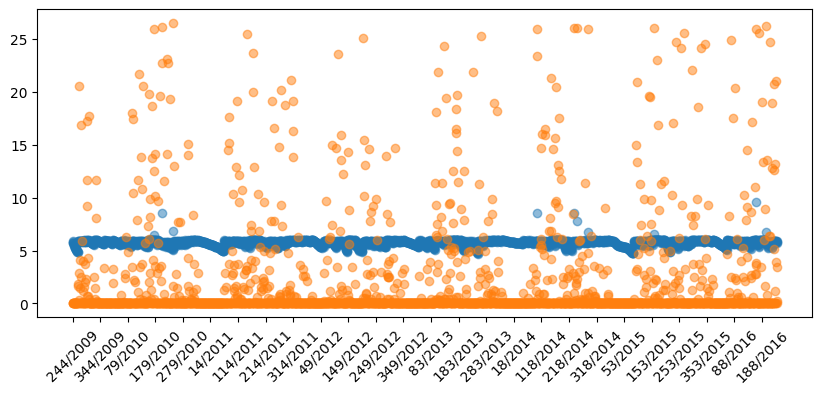

In [71]:
plt.figure(figsize=(10, 4))
plt.plot(dates, top_layer, 'o', alpha=0.5)
plt.plot(dates, top_percolation, 'o', alpha=0.5)
plt.xticks(dates[0::100], rotation=45)
plt.show()

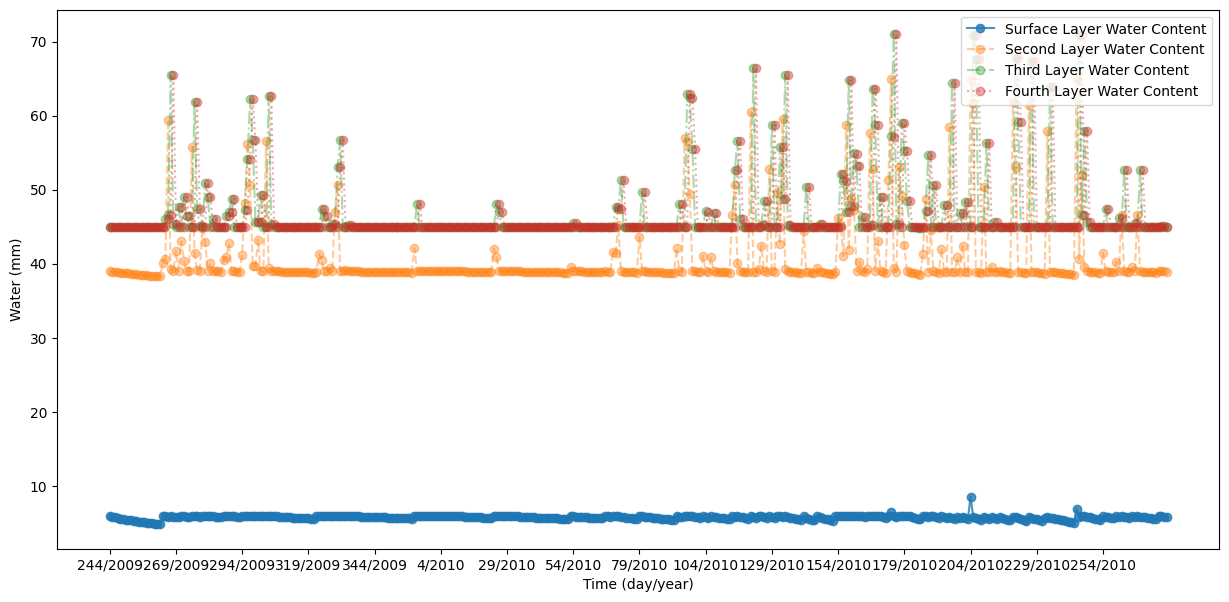

In [72]:
start_date = 0
end_date = 400
x_axis = dates[start_date:end_date]
x_ticks = dates[start_date:end_date:25]
#infil = infiltration[start_date:end_date]
top = top_layer[start_date:end_date]
second = second_layer[start_date:end_date]
third = third_layer[start_date:end_date]
fourth = fourth_layer[start_date:end_date]
plt.figure(figsize=(15, 7))
#plt.plot(x_axis, infil, 'o--', alpha=0.8)
plt.plot(x_axis, top, 'o-', alpha=0.8)
plt.plot(x_axis, second, 'o--', alpha=0.4)
plt.plot(x_axis, third, 'o-.', alpha=0.4)
plt.plot(x_axis, fourth, 'o:', alpha=0.4)
plt.xticks(x_ticks, rotation=0)
plt.xlabel("Time (day/year)")
plt.ylabel("Water (mm)")
plt.legend(["Surface Layer Water Content", "Second Layer Water Content", "Third Layer Water Content", "Fourth Layer Water Content"], loc="upper right")
plt.savefig("hyrodology_plot.png")
plt.show()

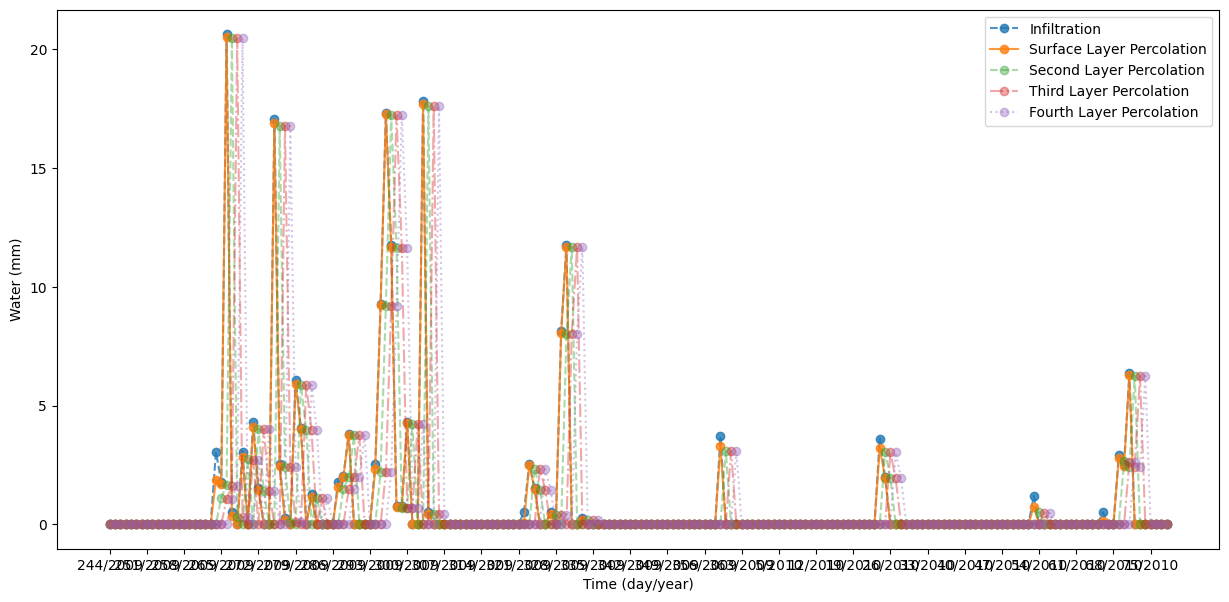

In [28]:
start_date = 0
end_date = 200
x_axis = dates[start_date:end_date]
x_ticks = dates[start_date:end_date:7]
infil = infiltration[start_date:end_date]
top = top_percolation[start_date:end_date]
second = second_percolation[start_date:end_date]
third = third_percolation[start_date:end_date]
fourth = fourth_percolation[start_date:end_date]
plt.figure(figsize=(15, 7))
plt.plot(x_axis, infil, 'o--', alpha=0.8)
plt.plot(x_axis, top, 'o-', alpha=0.8)
plt.plot(x_axis, second, 'o--', alpha=0.4)
plt.plot(x_axis, third, 'o-.', alpha=0.4)
plt.plot(x_axis, fourth, 'o:', alpha=0.4)
plt.xticks(x_ticks, rotation=0)
plt.xlabel("Time (day/year)")
plt.ylabel("Water (mm)")
plt.legend(["Infiltration", "Surface Layer Percolation", "Second Layer Percolation", "Third Layer Percolation", "Fourth Layer Percolation"])
plt.savefig("hyrodology_plot.png")
plt.show()

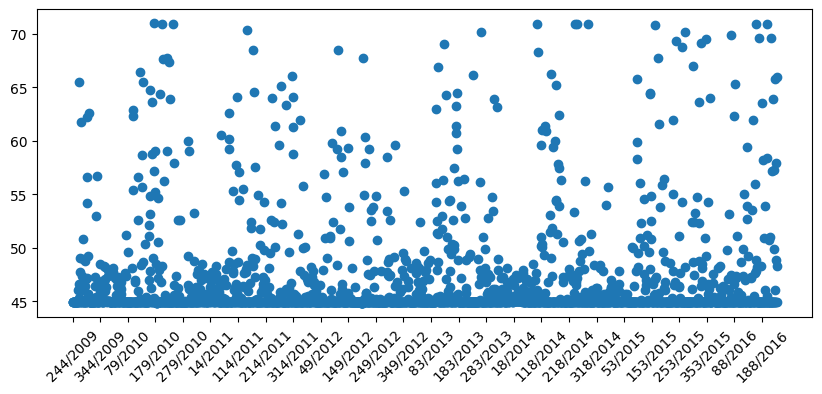

In [45]:
plt.figure(figsize=(10, 4))
plt.scatter(dates, third_layer)
plt.xticks(dates[0::100], rotation=45)
plt.show()

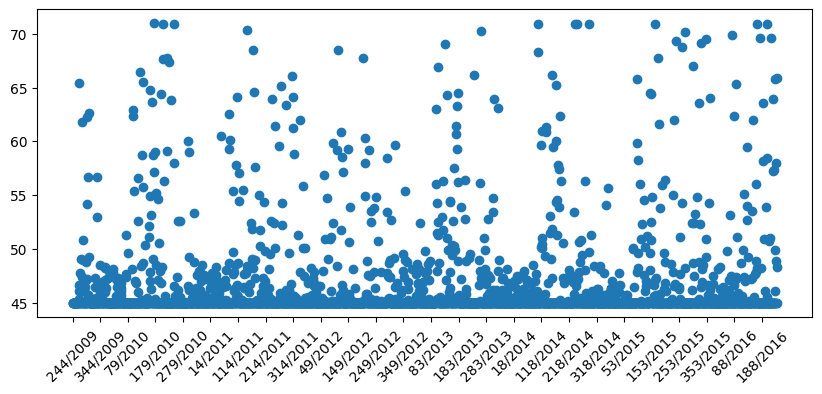

In [46]:
plt.figure(figsize=(10, 4))
plt.scatter(dates, fourth_layer)
plt.xticks(dates[0::100], rotation=45)
plt.show()

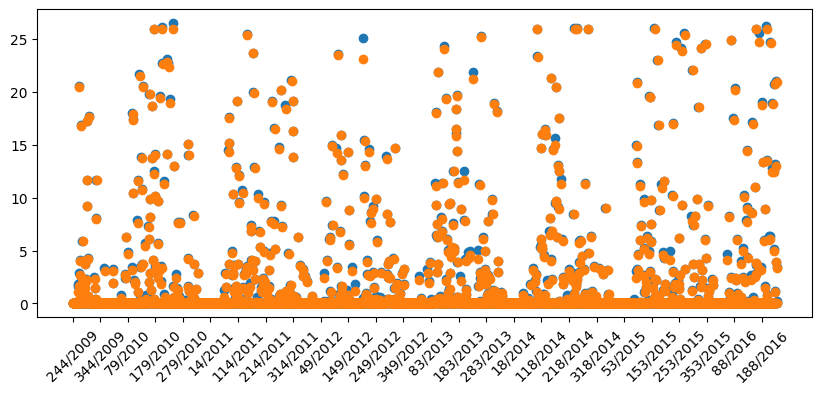

In [27]:
plt.figure(figsize=(10, 4))
plt.scatter(dates, top_percolation)
plt.scatter(dates, second_percolation)
plt.xticks(dates[0::100], rotation=45)
plt.show()

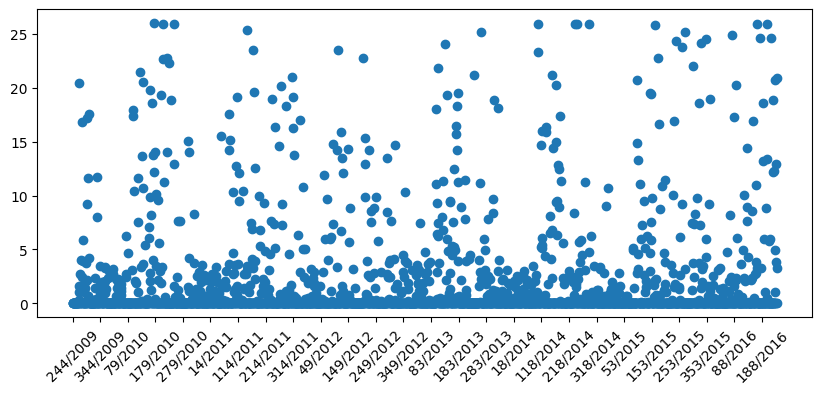

In [48]:
plt.figure(figsize=(10, 4))
plt.scatter(dates, third_percolation)
plt.xticks(dates[0::100], rotation=45)
plt.show()

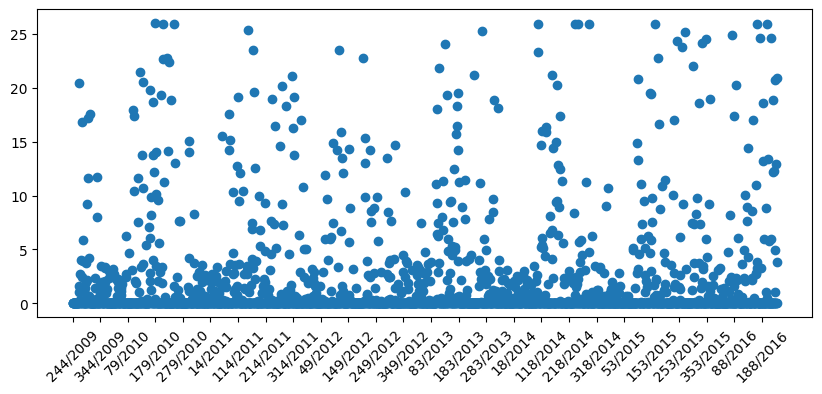

In [49]:
plt.figure(figsize=(10, 4))
plt.scatter(dates, fourth_percolation)
plt.xticks(dates[0::100], rotation=45)
plt.show()